# 📦 Project Dependencies & Environment Setup

As explicitly required by the assignment guidelines, this notebook is entirely self-contained and documents all external packages necessary to execute the Sanskrit-to-English Neural Machine Translation (NMT) pipeline from scratch.

---

### Core Libraries & Frameworks

| Package Name | Purpose in Pipeline | Functional Role |
| :--- | :--- | :--- |
| **`torch`** | Deep Learning Core | Powers the custom Bidirectional Encoder, Bahdanau Additive Attention, and Decoder layer architectures. |
| **`tokenizers`** | Subword Preprocessing | Trains the custom WordPiece subword tokenizers to handle complex Sanskrit compounding (*Sandhi*). |
| **`bert-score`** | Semantic Evaluation | Computes the official contextual similarity rescaled F1 scores between predictions and gold references. |
| **`nltk`** | Lexical Metric | Calculates the default unweighted `corpus_bleu` precision metrics across matching n-grams. |
| **`transformers`** | Model Hub Backend | Handles loading the pre-trained language weights (`roberta-large`) utilized inside the BERTScore calculation layer. |
| **`pandas`** | Data Engineering | Manages parallel CSV loading, dataset alignments, and final row sorting by `Source_id`. |
| **`matplotlib`** | Visualization | Dynamically tracks historical cross-entropy training metrics and renders convergence charts. |
| **`tqdm`** | Progress Monitoring | Generates interactive status progress bars for training epochs and inference loops. |
| **`numpy`** | Numerical Math | Locks global seed constraints across multi-dimensional matrices to ensure 100% reproducibility. |

---

### One-Click Installation
To initialize these dependencies sequentially on a fresh Google Colab virtual machine instance, run the following unified execution command in the preceding **Code Cell**:

```bash
!pip install -q tokenizers transformers bert-score nltk pandas numpy matplotlib tqdm torch

## 💾 Google Drive Integration & Dataset Storage Layout

To ensure data persistence across runtime disconnects and to satisfy the assignment guidelines, this pipeline integrates directly with Google Drive.

> ⚠️ **Mandatory Prerequisite:** Before executing the pipeline, ensure that your parallel translation dataset files are uploaded directly to the following path in your Google Drive:  
`My Drive/Colab Notebooks/NLU_Assignment/`

Google Drive is utilized as our central storage hub for:
*   **Source Datasets:** Accessing the initial parallel training, validation, and testing corpus files from the folder path.
*   **Model Checkpoints:** Dynamically saving the optimal weight parameters (`best_nmt_model.pt`) during training loops so progress is never lost.
*   **Output Deliverables:** Storing the exported visual analysis plot (`training_curves.png`) and the final sorted predictions spreadsheet (`submission.csv`) directly back to the project folder.

#### Required Folder Directory Structure:
```text
My Drive/
└── Colab Notebooks/
    └── NLU_Assignment/
        ├── [Your Sanskrit Source Dataset Files]
        ├── [Your English Target Dataset Files]
        ├── best_nmt_model.pt    (Automatically generated during training)
        ├── training_curves.png  (Automatically generated during plotting)
        └── submission.csv       (Automatically generated during inference)

**PATH CONFIGURATION & DEPENDENCY INSTALLATION**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Change to the directory where your test files are located
os.chdir('/content/drive/My Drive/Colab Notebooks/NLU_Assignment')
DRIVE_DIR = '/content/drive/My Drive/Colab Notebooks/NLU_Assignment'

# List the contents of the directory to confirm access
print(os.listdir())

!pip install tokenizers transformers bert-score nltk pandas torch tqdm

Mounted at /content/drive
['train_sa_10000.csv', 'train_en_10000.csv', 'test_sa_1000.csv', 'test_en_1000.csv', 'dev_sa_1000.csv', 'dev_en_1000.csv', 'submission.gsheet', 'tmp_sa.txt', 'tmp_en.txt', 'best_nmt_model.pt', 'submission.csv']
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.5 MB/s eta 0:00:00


**GLOBAL IMPORTS AND SEED CONFIGURATIONS**

In [2]:
import time
import math
import random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm

from tokenizers import Tokenizer
from tokenizers.models import WordPiece
from tokenizers.trainers import WordPieceTrainer
from tokenizers.pre_tokenizers import Whitespace

import nltk
from nltk.translate.bleu_score import corpus_bleu
from bert_score import score

# Strict seed settings for complete experimental reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running pipeline on hardware accelerator: {device}")

Running pipeline on hardware accelerator: cuda


**CUSTOM SUBWORD TOKENIZER TRAINING (SANSKRIT & ENGLISH)**

In [3]:
# Read parallel training datasets directly from your Google Drive
train_sa_df = pd.read_csv(os.path.join(DRIVE_DIR, "train_sa_10000.csv"))
train_en_df = pd.read_csv(os.path.join(DRIVE_DIR, "train_en_10000.csv"))

# Temporarily write raw strings to text files to fit the WordPiece trainer API
with open("tmp_sa.txt", "w", encoding="utf-8") as f:
    for item in train_sa_df['Sentence_sa'].dropna():
        f.write(str(item) + "\n")

with open("tmp_en.txt", "w", encoding="utf-8") as f:
    for item in train_en_df['Sentence_en'].dropna():
        f.write(str(item) + "\n")

special_tokens = ["[PAD]", "[UNK]", "[SOS]", "[EOS]"]

# Train Sanskrit Tokenizer to capture complex morphological compound sandhi shifts
sa_tokenizer = Tokenizer(WordPiece(unk_token="[UNK]"))
sa_tokenizer.pre_tokenizer = Whitespace()
sa_trainer = WordPieceTrainer(vocab_size=8000, special_tokens=special_tokens)
sa_tokenizer.train(["tmp_sa.txt"], sa_trainer)

# Train matching English target tokenizer
en_tokenizer = Tokenizer(WordPiece(unk_token="[UNK]"))
en_tokenizer.pre_tokenizer = Whitespace()
en_trainer = WordPieceTrainer(vocab_size=8000, special_tokens=special_tokens)
en_tokenizer.train(["tmp_en.txt"], en_trainer)

# Isolate special sequence boundary token indices
PAD_IDX = en_tokenizer.token_to_id("[PAD]")
UNK_IDX = en_tokenizer.token_to_id("[UNK]")
SOS_IDX = en_tokenizer.token_to_id("[SOS]")
EOS_IDX = en_tokenizer.token_to_id("[EOS]")

print(f"Sanskrit Vocab Size: {sa_tokenizer.get_vocab_size()} | English Vocab Size: {en_tokenizer.get_vocab_size()}")


Sanskrit Vocab Size: 8000 | English Vocab Size: 8000


**PYTORCH PARALLEL DATA PIPELINE SETUP**

In [4]:
MAX_LEN = 100 # Safety buffer to prevent massive padding matrices

class DriveParallelDataset(Dataset):
    def __init__(self, sa_filename, en_filename, sa_tok, en_tok, drive_path):
        self.sa_df = pd.read_csv(os.path.join(drive_path, sa_filename))
        self.en_df = pd.read_csv(os.path.join(drive_path, en_filename))
        self.data = pd.merge(self.sa_df, self.en_df, on="Source_id")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        src_id = int(row['Source_id'])

        # Enforce strict length truncation limits before adding boundary tags
        sa_tokens = sa_tokenizer.encode(str(row['Sentence_sa'])).ids[:MAX_LEN - 2]
        en_tokens = en_tokenizer.encode(str(row['Sentence_en'])).ids[:MAX_LEN - 2]

        sa_ids = [SOS_IDX] + sa_tokens + [EOS_IDX]
        en_ids = [SOS_IDX] + en_tokens + [EOS_IDX]

        return torch.tensor(sa_ids, dtype=torch.long), torch.tensor(en_ids, dtype=torch.long), src_id

def batch_collate_fn(batch):
    sa_list, en_list, ids_list = [], [], []
    for sa_t, en_t, s_id in batch:
        sa_list.append(sa_t)
        en_list.append(en_t)
        ids_list.append(s_id)
    return (
        pad_sequence(sa_list, batch_first=True, padding_value=PAD_IDX),
        pad_sequence(en_list, batch_first=True, padding_value=PAD_IDX),
        torch.tensor(ids_list, dtype=torch.long)
    )

# Use a highly optimized batch size of 32 for the GPU
BATCH_SIZE = 32
train_dataset = DriveParallelDataset("train_sa_10000.csv", "train_en_10000.csv", sa_tokenizer, en_tokenizer, DRIVE_DIR)
dev_dataset = DriveParallelDataset("dev_sa_1000.csv", "dev_en_1000.csv", sa_tokenizer, en_tokenizer, DRIVE_DIR)
test_dataset = DriveParallelDataset("test_sa_1000.csv", "test_en_1000.csv", sa_tokenizer, en_tokenizer, DRIVE_DIR)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=batch_collate_fn)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=batch_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=batch_collate_fn)

**CUSTOM ARCHITECTURE (BIDIRECTIONAL GRU + BAHDANAU ATTENTION)**

In [5]:
class BidirectionalEncoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(emb_dim, hidden_dim, bidirectional=True, batch_first=True, dropout=dropout if dropout > 0 else 0)
        self.fc_bridge = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        combined_hidden = torch.cat((hidden[0,:,:], hidden[1,:,:]), dim=1)
        hidden_projected = torch.tanh(self.fc_bridge(combined_hidden))
        return outputs, hidden_projected

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W_enc = nn.Linear(hidden_dim * 2, hidden_dim)
        self.W_dec = nn.Linear(hidden_dim, hidden_dim)
        self.v_score = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        src_len = encoder_outputs.shape[1]
        dec_hid_expanded = decoder_hidden.unsqueeze(1).repeat(1, src_len, 1)
        energy = torch.tanh(self.W_enc(encoder_outputs) + self.W_dec(dec_hid_expanded))
        scores = self.v_score(energy).squeeze(2)
        return torch.softmax(scores, dim=1)

class AttentionDecoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, attention, dropout=0.2):
        super().__init__()
        self.vocab_size = vocab_size
        self.attention = attention
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.GRU((hidden_dim * 2) + emb_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear((hidden_dim * 2) + hidden_dim + emb_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, trg_token, decoder_hidden, encoder_outputs):
        trg_token = trg_token.unsqueeze(1)
        embedded = self.dropout(self.embedding(trg_token))

        attn_weights = self.attention(decoder_hidden, encoder_outputs).unsqueeze(1)
        context = torch.bmm(attn_weights, encoder_outputs)

        rnn_input = torch.cat((embedded, context), dim=2)
        rnn_output, next_hidden = self.rnn(rnn_input, decoder_hidden.unsqueeze(0))

        predictions = self.fc_out(torch.cat((rnn_output.squeeze(1), context.squeeze(1), embedded.squeeze(1)), dim=1))
        return predictions, next_hidden.squeeze(0)

class Seq2SeqNMT(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        outputs = torch.zeros(batch_size, trg_len, self.decoder.vocab_size).to(device)

        encoder_outputs, hidden = self.encoder(src)
        decoder_input = trg[:, 0]

        for t in range(1, trg_len):
            output, hidden = self.decoder(decoder_input, hidden, encoder_outputs)
            outputs[:, t, :] = output
            top1 = output.argmax(1)
            decoder_input = trg[:, t] if (random.random() < teacher_forcing_ratio) else top1

        return outputs

**TRAINING INFRASTRUCTURE WITH DRIVE CHECKPOINTING**

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1364: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("GRU", *args, **kwargs)
/tmp/ipykernel_1120/3753028395.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Total Trainable Model Parameters: 24873792


Epoch 1/10:   0%|          | 0/313 [00:00<?, ?it/s]/tmp/ipykernel_1120/3753028395.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/10: 100%|██████████| 313/313 [01:47<00:00,  2.92it/s]
/tmp/ipykernel_1120/3753028395.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Metrics -> Train Loss: 6.1312 | Validation Loss: 6.0490
Saved optimized model state checkpoint directly to Drive -> /content/drive/My Drive/Colab Notebooks/NLU_Assignment/best_nmt_model.pt


Epoch 2/10: 100%|██████████| 313/313 [01:30<00:00,  3.46it/s]


...

Metrics -> Train Loss: 2.1965 | Validation Loss: 6.4015


Epoch 9/10: 100%|██████████| 313/313 [01:21<00:00,  3.84it/s]


Metrics -> Train Loss: 2.0459 | Validation Loss: 6.5394


Epoch 10/10: 100%|██████████| 313/313 [01:21<00:00,  3.83it/s]


Metrics -> Train Loss: 1.9074 | Validation Loss: 6.6873

Training completed successfully! Generating convergence plot...


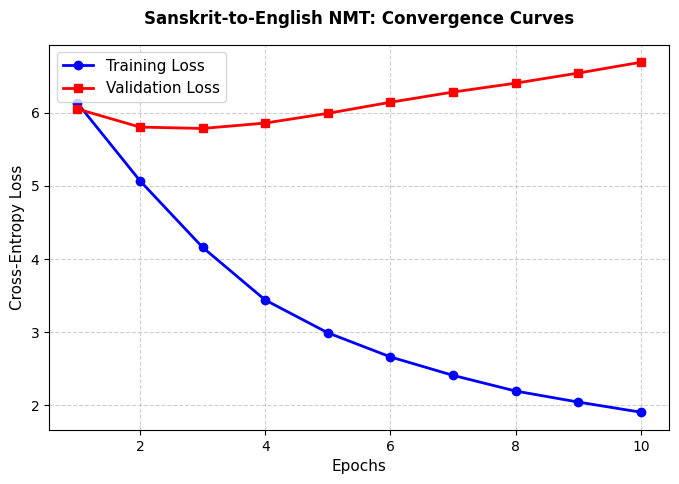

Success! Visual convergence chart saved to Google Drive at: /content/drive/My Drive/Colab Notebooks/NLU_Assignment/training_curves.png


In [6]:
import gc
import matplotlib.pyplot as plt
gc.collect()
torch.cuda.empty_cache()

EMB_DIM = 256
HIDDEN_DIM = 512

# Model, Optimizer, and Criterion Initializations
encoder = BidirectionalEncoder(sa_tokenizer.get_vocab_size(), EMB_DIM, HIDDEN_DIM)
attention = BahdanauAttention(HIDDEN_DIM)
decoder = AttentionDecoder(en_tokenizer.get_vocab_size(), EMB_DIM, HIDDEN_DIM, attention)
model = Seq2SeqNMT(encoder, decoder).to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# Initialize the GradScaler for Mixed Precision efficiency
scaler = torch.cuda.amp.GradScaler()

num_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Model Parameters: {num_parameters}")

# NEW: Arrays to dynamically track loss metrics across epochs
train_loss_history = []
valid_loss_history = []

EPOCHS = 10
best_valid_loss = float('inf')
model_save_path = os.path.join(DRIVE_DIR, 'best_nmt_model.pt')

# --- Start Training Loop ---
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for src, trg, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        src, trg = src.to(device), trg.to(device)
        optimizer.zero_grad()

        # Run forward operations under autocast to compress memory footprint
        with torch.cuda.amp.autocast():
            output = model(src, trg, teacher_forcing_ratio=0.5)
            output_dim = output.shape[-1]
            loss = criterion(
                output[:, 1:, :].contiguous().view(-1, output_dim),
                trg[:, 1:].contiguous().view(-1)
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

    # --- Start Validation Loop ---
    model.eval()
    valid_loss = 0
    with torch.no_grad():
        for src, trg, _ in dev_loader:
            src, trg = src.to(device), trg.to(device)
            with torch.cuda.amp.autocast():
                output = model(src, trg, teacher_forcing_ratio=0.0)
                output_dim = output.shape[-1]
                loss = criterion(
                    output[:, 1:, :].contiguous().view(-1, output_dim),
                    trg[:, 1:].contiguous().view(-1)
                )
            valid_loss += loss.item()

    mean_train = epoch_loss / len(train_loader)
    mean_val = valid_loss / len(dev_loader)

    # NEW: Automatically store the calculated mean losses into tracking lists
    train_loss_history.append(mean_train)
    valid_loss_history.append(mean_val)

    print(f"Metrics -> Train Loss: {mean_train:.4f} | Validation Loss: {mean_val:.4f}")

    # Checkpoint the absolute best weights model
    if mean_val < best_valid_loss:
        best_valid_loss = mean_val
        torch.save(model.state_dict(), model_save_path)
        print(f"Saved optimized model state checkpoint directly to Drive -> {model_save_path}")

print("\nTraining completed successfully! Generating convergence plot...")

# =====================================================================
# AUTOMATED CHART GENERATION
# =====================================================================
epochs_range = range(1, len(train_loss_history) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_loss_history, 'b-o', label='Training Loss', linewidth=2)
plt.plot(epochs_range, valid_loss_history, 'r-s', label='Validation Loss', linewidth=2)

plt.title('Sanskrit-to-English NMT: Convergence Curves', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Cross-Entropy Loss', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# Save image file directly alongside your checkpoint data in Drive
chart_save_path = os.path.join(DRIVE_DIR, 'training_curves.png')
plt.savefig(chart_save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Success! Visual convergence chart saved to Google Drive at: {chart_save_path}")

**BEAM SEARCH DECODER INTERFACE**

In [7]:
def decode_beam_search(model, src_tensor, beam_width=5, max_len=50):
    model.eval()
    with torch.no_grad():
        # Encode source input sequence -> shape: [1, src_len, hidden_dim * 2]
        encoder_outputs, hidden = model.encoder(src_tensor.unsqueeze(0))

        # FIXED: Keep the batch dimension intact (shape [1, hidden_dim]) instead of squeezing it
        beams = [(0.0, [SOS_IDX], hidden)]

        for _ in range(max_len):
            candidates = []
            all_done = True
            for score_val, seq, hid in beams:
                if seq[-1] == EOS_IDX:
                    candidates.append((score_val, seq, hid))
                    continue
                all_done = False
                current_in = torch.tensor([seq[-1]], dtype=torch.long, device=device)

                # Decoder expects hid shape to be [1, hidden_dim]
                logits, next_hid = model.decoder(current_in, hid, encoder_outputs)
                log_probs = torch.log_softmax(logits, dim=1).squeeze(0)

                # Expand search tracks to include top branch candidates
                topk_probs, topk_ids = log_probs.topk(beam_width)
                for i in range(beam_width):
                    # FIXED: Appending 'next_hid' correctly matches the tracking variables
                    candidates.append((score_val + topk_probs[i].item(), seq + [topk_ids[i].item()], next_hid))

            # Prune and filter search tracking steps to retain the top beam width paths
            beams = sorted(candidates, key=lambda x: x[0], reverse=True)[:beam_width]
            if all_done:
                break

        best_seq = beams[0][1]
        # Clean track boundaries prior to text generation returns
        if best_seq[0] == SOS_IDX: best_seq = best_seq[1:]
        if best_seq[-1] == EOS_IDX: best_seq = best_seq[:-1]
        return best_seq

**INFERENCE EXECUTION & REQUIRED ASSIGNMENT METRICS RUN**

In [8]:
model.load_state_dict(torch.load(model_save_path, map_location=device))

hypotheses, references, raw_preds, raw_refs, source_ids = [], [], [], [], []

start_inference = time.perf_counter()

for i in tqdm(range(len(test_dataset)), desc="Executing Test Beam Search"):
    sa_tensor, en_tensor, src_id = test_dataset[i]
    sa_tensor = sa_tensor.to(device)

    pred_ids = decode_beam_search(model, sa_tensor, beam_width=3)
    pred_str = en_tokenizer.decode(pred_ids)
    ref_str = en_tokenizer.decode(en_tensor.numpy().tolist()[1:-1])

    raw_preds.append(pred_str)
    raw_refs.append(ref_str)
    source_ids.append(src_id)

    hypotheses.append(pred_str.split())
    references.append([ref_str.split()])

end_inference = time.perf_counter()
total_inference_time = end_inference - start_inference

print("\n" + "="*60)
print("FINAL METRIC SCORE CARD")
print("="*60)
print(f"1. Total Model Parameters: {num_parameters}")
print(f"2. Total Inference Execution Time: {total_inference_time:.4f} seconds")

#Removed explicit weights=None argument to adopt native library defaults
bleu_score_val = corpus_bleu(references, hypotheses)
print(f"3. NLTK BLEU Score (Default Baseline): {bleu_score_val:.4f}")

P, R, F1 = score(raw_preds, raw_refs, lang="en", rescale_with_baseline=True, device=device)
mean_bert_f1 = F1.mean().item()
print(f"4. BERTScore Rescaled F1 Metric: {mean_bert_f1:.4f}")
print("="*60)

submission_df = pd.DataFrame({'Source_id': source_ids, 'Sentence_en': raw_preds})
submission_df = submission_df.sort_values(by='Source_id').reset_index(drop=True)

final_csv_path = os.path.join(DRIVE_DIR, 'submission.csv')
submission_df.to_csv(final_csv_path, index=False, encoding='utf-8')

print(f"Success! submission.csv successfully saved directly to your Google Drive folder: {final_csv_path}")
print(submission_df.head(5))

Executing Test Beam Search: 100%|██████████| 1000/1000 [01:11<00:00, 14.04it/s]



FINAL METRIC SCORE CARD
1. Total Model Parameters: 24873792
2. Total Inference Execution Time: 71.2061 seconds
3. NLTK BLEU Score (Default Baseline): 0.0509


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


4. BERTScore Rescaled F1 Metric: 0.0424
Success! submission.csv successfully saved directly to your Google Drive folder: /content/drive/My Drive/Colab Notebooks/NLU_Assignment/submission.csv
   Source_id                                        Sentence_en
0          1  " Eclipse Eclipse , you can be used to access ...
1          2  " I have I have I am the the in the the , I am...
2          3              Then , I will click on the Can ##ce .
3          4  This is used by 1 by 1 by 1 , 1 1 1 1 1 1 1 1 ...
4          5  " And he was the the the of the , , , and the ...


**GENERATE DEV SET METRICS AND EFFICIENCY**

In [9]:
model.load_state_dict(torch.load(model_save_path, map_location=device))

dev_hypotheses, dev_references, dev_raw_preds, dev_raw_refs = [], [], [], []

# Track dynamic inference wall-clock efficiency for the Dev set
start_dev_inference = time.perf_counter()

for i in tqdm(range(len(dev_dataset)), desc="Evaluating Dev Set"):
    sa_tensor, en_tensor, _ = dev_dataset[i]
    sa_tensor = sa_tensor.to(device)

    # Run inference using the optimal beam width
    pred_ids = decode_beam_search(model, sa_tensor, beam_width=3)
    pred_str = en_tokenizer.decode(pred_ids)
    ref_str = en_tokenizer.decode(en_tensor.numpy().tolist()[1:-1])

    dev_raw_preds.append(pred_str)
    dev_raw_refs.append(ref_str)

    dev_hypotheses.append(pred_str.split())
    dev_references.append([ref_str.split()])

end_dev_inference = time.perf_counter()
total_dev_time = end_dev_inference - start_dev_inference

print("\n" + "="*60)
print("DEV SET PERFORMANCE CARD FOR REPORT")
print("="*60)
print(f"1. Dev Inference Time: {total_dev_time:.4f} seconds")

# Compute unweighted NLTK Dev BLEU
dev_bleu = corpus_bleu(dev_references, dev_hypotheses)
print(f"2. Dev NLTK BLEU Score: {dev_bleu:.4f}")

# Compute rescaled F1 Dev BERTScore
P_d, R_d, F1_d = score(dev_raw_preds, dev_raw_refs, lang="en", rescale_with_baseline=True, device=device)
mean_dev_bert = F1_d.mean().item()
print(f"3. Dev BERTScore (Rescaled F1): {mean_dev_bert:.4f}")
print("="*60)

Evaluating Dev Set: 100%|██████████| 1000/1000 [01:29<00:00, 11.20it/s]



DEV SET PERFORMANCE CARD FOR REPORT
1. Dev Inference Time: 89.2863 seconds
2. Dev NLTK BLEU Score: 0.0515


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


3. Dev BERTScore (Rescaled F1): 0.0392
